In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

ImportError: DLL load failed while importing _multiarray_umath: 지정된 모듈을 찾을 수 없습니다.

ImportError: DLL load failed while importing _multiarray_umath: 지정된 모듈을 찾을 수 없습니다.

ImportError: numpy._core.multiarray failed to import

In [ ]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [ ]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
# train_scaled = train_input / 255.0
# test_scaled = test_input / 255.0
import numpy as np

# 정규화를 하기 위해 학습 데이터의 평균과 분산 구하기
mean = np.mean(train_input)
std  = np.std(train_input)

# 데이터 정규화하기
# 0으로 나눠지는 것 (=무한대로 수렴)을 막기 위해 1e-7 더기기
train_scaled = (train_input-mean)/(std+1e-7)
test_scaled  = (test_input-mean) /(std+1e-7)


In [ ]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))

In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    optimizer='adam'
    )


Epoch 1/20
1688/1688 - 9s - 5ms/step - accuracy: 0.8044 - loss: 0.5424 - val_accuracy: 0.8463 - val_loss: 0.4177
Epoch 2/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8441 - loss: 0.4275 - val_accuracy: 0.8593 - val_loss: 0.3804
Epoch 3/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8554 - loss: 0.3959 - val_accuracy: 0.8683 - val_loss: 0.3643
Epoch 4/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8634 - loss: 0.3765 - val_accuracy: 0.8710 - val_loss: 0.3511
Epoch 5/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8681 - loss: 0.3608 - val_accuracy: 0.8738 - val_loss: 0.3484
Epoch 6/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8716 - loss: 0.3511 - val_accuracy: 0.8690 - val_loss: 0.3545
Epoch 7/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8759 - loss: 0.3366 - val_accuracy: 0.8760 - val_loss: 0.3497
Epoch 8/20
1688/1688 - 11s - 6ms/step - accuracy: 0.8760 - loss: 0.3302 - val_accuracy: 0.8815 - val_loss: 0.3423
Epoch 9/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8791 - loss: 0.3249 - val_accuracy: 0.8733 -

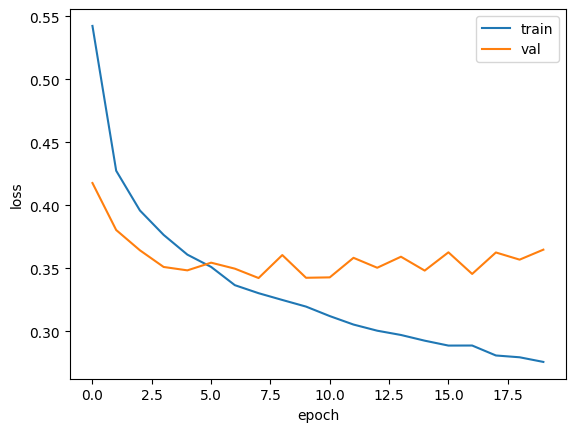

In [ ]:
history = model.fit(train_scaled, train_target, epochs=20, verbose=2, validation_split = 0.1)
history.history.keys()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
model.summary()

In [ ]:
model.evaluate(test_scaled, test_target)

콜백은 프로그래밍에서 다른 함수의 인수로 전달되는 하마수를 의미합니다.  
<br>
콜백 : 훈련과정 중간에 어떤 작업을 수행하게 해주는 객체  
fit 메서드의 callbacks = []에 리스트로 전달하여 사용  
<br>
ModelCheckpoit 콜백은 기본적으로 에포크마다 모델을 저장한다.  
save_best_only = True는 가장 낮은 검증 점수를 만드는 모델을 저장.  
<br>
조기 종료 콜백 필요 = EarlyStopping  
patience = 3이면 3번까지 연속 검증 손실 점수가 향샹되지 않으면 훈련 중지  
restore_best_weights = True 가장 낮은 검증 손실을 낸 모델 파라미터로 되돌린다.
